(ch:qutip)=
# Numerical calculation using QuTip

A summary of QuTip usage for computing open quantum system is given.   Only modules and functions used in this note are included. 

## Basics

### Loading QuTip modules

First of all, `numpy` and `matplotlib` must be loaded since `QuTip` uses them. It is assumed that they are loaded as follows:

```
import numpy as np
import matplotlib.pyplot as plt
```

Like other python packages, there are many ways to load the modules in QuTip. 

1. Load everything with alias `qt`.  This method avoids name conflict. You can use any alias you want.  
  ```
    import qutip as qt
  ```

2. Load everything without alias.  Simple and convenient but it may cause name conflict.
  ```
    from qutip import *
  ```

3. Load only modules you use.
  ```
    from qutip import (
    basis, qeye, tensor, sigmam, sigmap, sigmaz,
    mcsolve, expect
    )
  ```



### Quantum objects

Mathematically, elements of quantum mechanics are state vector: $|\psi\rangle$, density operator: $\rho$, and operators as observables: $H$.  In traditional numerical methods, they are all expressed as a matrix.  QuTip treats them as different python objects known as qantum objects or `Qobj`.  Each object consists of at least four parts:
1. **type**: ket $|\psi\rangle$, bra $\langle\psi|$, operator $\hat{O}$, super operator $\mathcal{L}$.
2. **dimension**:  size of the object, for example a 4-by-4 matrix [[4],[4]] or a tensor [[2,2],[2,2]] [both have the same shape(4,4)].
3. **shape**: shape of the object.  This is the shape of data, which is essentially the shape of an array.
4. **data**: actual data in a matrix form.

You cannot define quantum object as a simple matrix.  For example,  assigning a column matrix does not create a state vector. There are two methods to create desired quantum objects.

1. Use a build-in function such as `basis()` for a qubit state vector and `sigmaz()` for the Pauli operator $\sigma^z$.
2. Convert an array to a quantum object using `Qobj()` function.

The following example generate state vector $|\psi\rangle = (|0\rangle + |1\rangle)/\sqrt{2} = \frac{1}{\sqrt{2}} \begin{pmatrix}1\\1\end{pmatrix}$ and an operator $A = \sigma^x + \sigma^z = \begin{pmatrix} 1& 1\\1 & -1\end{pmatrix}$.  Printout shows their object type.

**Using the build-in functions**

In [46]:
import numpy as np
from qutip import *

psi = (basis(2,0) + basis(2,1))/np.sqrt(2)
print(psi)

A = sigmax()+sigmaz()
print(A)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  1.]
 [ 1. -1.]]


**Converting from arrays**

In [47]:
psi0 = np.array([1,1])/np.sqrt(2)
psi = Qobj(psi0)
print(psi)

A0 = np.array([[1,1],[1,-1]])
A = Qobj(A0)
print(A)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  1.]
 [ 1. -1.]]


To convert a quantum object to a numpy array, use the method `full`.  For example, if A is a Qobj, `A.full()` is a standard numpy array.

In [48]:
print(A.full())

[[ 1.+0.j  1.+0.j]
 [ 1.+0.j -1.+0.j]]


```{admonition} Quantum Object
:class: top 
:name: adm:qobj

Operation between incompatible quantum objects is not allowed in QuTip.  Suppose that two operators A and B are expressed in 4-by-4 matrix.  Their shape is (4,4).  However, if A is a tensor product of 2-by-2 matrices and B is not, their dimensions are [[2,2],[2,2]] and [[4],[4]],respectively.  Hence they belong to different quantum objects and thus A+B is not allowed due to incompatible dimensions.
```

### Standard operations on quantum objects

1. standard operators
   * identity: &ensp;`qeye(D)`  where D is the dimension of Hilbert space.
   * Pauli operators $\sigma^x$, $\sigma^y$, $\sigma^z$: &ensp; `sigmax()`, `sigmay()`, `sigmaz()`
   * raising and lowering operator $\sigma^+$, $\sigma^-$: &ensp; `sigmap()`, `sigmam()`
2. operations on operators
   * adjoint: $A^\dagger$:&ensp; `A.dag()`
   * trace: $\text{tr}(A)$: &ensp; `A.tr()`
   * partial trace: $\text{tr}_{j}(A)$: &ensp; `A.ptrace(j)` where `j` is the index for the subsystem.
   * tensor product $C = A \otimes B$: &ensp; `C=tensor(A,B)`
   * eigenvalues & eigenvectors of operator: &ensp; `A.eigensystems()` which returns eigenvalues $\lambda_i$ and eigenvevtors $|u_i\rangle$ as `lam, vec = A.eigensystems()`
3. standard states (based on qubits) 
   * basis kets: &ensp; `basis(D,j)` where `D` is the dimension and `j` for the j-th ket.
   * single state $(|01\rangle - |10\rangle)/\sqrt{2}$: &ensp; `singlet_state()`   (This is equivalent to `bell_state('11')`.
   * general Bell state:
     * $(|00\rangle + |11\rangle)/\sqrt{2}$: &ensp; bell_state('00')
     * $(|00\rangle - |11\rangle)/\sqrt{2}$: &ensp; bell_state('01')
     * $(|01\rangle + |10\rangle)/\sqrt{2}$: &ensp; bell_state('10')
     * $(|01\rangle - |10\rangle)/\sqrt{2}$: &ensp; bell_state('11')
   * random ket: &ensp; `random_ket(D)`
   * random density operator: &ensp; `random_dm()`.
4. operations on states
   * bra: if `psi` is a ket, the corresponding bra is just its adjoint: &ensp;`psi.dag()`.  The inner product $\langle\phi|\psi\rangle$ is `phi.dag()*psi`.
   * norm: &ensp; `psi.norm()`
   * normalization: &ensp; `psi.unit()`
   * generating a density operator from a ket $\rho = |\psi\rangle\langle\psi|$: &ensp; `ket2dm(psi)`.
5. expectation values and matrix elements
   * expectation value of A with state ket, $\langle A \rangle = \langle\psi|A|\psi\rangle$: &ensp; `expect(A,psi)`.
   * expectation value of A with density matrix, $\langle A \rangle = \text{tr}(A \rho)$:  &ensp; `expect(A,rho)`.
   * matrix element of A, $\langle\psi |A| \phi \rangle$:  &ensp; `A.matrix_element(psi, phi)`.

## Quantum master equation

QuTip includes quantum master equation solvers and many utilities to evaluate physical quantities using the output from the solver.  Here is a brief summary of basic operations.

### Defining a quantum master equation

We want to solve a quantum master equation $\frac{d}{dt}\rho = \mathcal{L} \rho$ where $\mathcal{L}$ is a Liouville super operator (Liouvillian). (See {numref}`ch:openqm-qme`.)  The Liouville superoperators are uniquely determined by the system Hamiltonian $H$ and a set of dissipators $\mathcal{D}$ such that

$$
\mathcal{L} \rho = -i [H,\rho] + \sum_{ij} \gamma_{ij} \mathcal{D}_{ij} \rho
$$

where 

$$
\mathcal{D}_{ij} \rho = A_{j} \rho A^{\dagger}_{i} - \frac{1}{2} \left(A^{\dagger}_{i} A_{j} \rho + \rho A^{\dagger}_{i} A_{j} \right)
$$

Many QuTip utilities are tuned for $\gamma_{ij} = \gamma_{j} \delta{ij}$.  You can always eliminate the off-diagonal terms by diagonalizing $\gamma_{ij}$. There is a brute force  method without diagonalization, which we discuss later. 

**Defining Liuovillian**

 Here the Liouvillian is assumned to take the following standard form


$$
\mathcal{L} \rho = -i [H,\rho] + \sum_{i} \gamma_{j} \left[ A_{j} \rho A^{\dagger}_{j} - \frac{1}{2} \left(A^{\dagger}_{j} A_{j} \rho + \rho A^{\dagger}_{j} A_{j} \right)\right]
$$

You can see that the Liouvillian is uniquely defined by the system Hamiltonian $H$ and the collapse operators $\sqrt{\gamma_{j}} A_{j}$. In QuTip we define the Liouvillian using a function `liouvillian(H,c_ops)` where `H` is a system Hamiltonian and `c_ops` is a list of collapse operators. The following example construct a Liouvillian with $H=\frac{\omega}{2}\sigma^z$ and two collapse operators $\sqrt{\gamma} \sigma^{+}$ and $\sqrt{\gamma} \sigma^{-}$. The print out shows that the type of Liouvillian is `super`, meaning super operator.

In [49]:
import numpy as np
from qutip import *

omega = 1.0
gamma = 0.1
H = omega/2 * sigmaz()
c_ops = [np.sqrt(gamma)*sigmap(), np.sqrt(gamma)*sigmam()]

L = liouvillian(H,c_ops)
print(L)

Quantum object: dims=[[[2], [2]], [[2], [2]]], shape=(4, 4), type='super', dtype=CSR, isherm=False
Qobj data =
[[-0.1+0.j  0. +0.j  0. +0.j  0.1+0.j]
 [ 0. +0.j -0.1+1.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -0.1-1.j  0. +0.j]
 [ 0.1+0.j  0. +0.j  0. +0.j -0.1+0.j]]


**Steady state**

The solution to any quantum master equation is known to asymptotically approaches to a steady state $\rho_{ss}$ which satisfies $\mathcal{L}\rho_{ss} = 0$. As we saw in the previous sections, the steady state plays important roles in quantum optics. We can find it without explicitly solving the master equation using `steadystate(L)` function in QuTip. The following example use the Liouvillian defined in the above.

In [50]:
rho_ss = steadystate(L)
print(rho_ss)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]


**Time evolution of density operator**

Now, we solve the quantum master equation and find the time-evolution of density operator.  First, we need to a set of sampling times.  The density operator and other information at the given times are recorded and returned by `mesolve()`.  This function takes various arguments some are required and others are optional. Here is a minimum set of rquired qurgument:

```
result = mesolve(H, psi0, times, c_ops, e_ops=...)
```

where $H$ is the system Hamiltonian, `psi0` is an initial wavefunction,  `times` is an array of sampling times, `c_ops` is a list of collapse operators.  These four operators are positional arguments. `e_ops` is a list of observables to be measured. It is  a keyword only argument.  It should be used as `e_ops = list-of-operators`.  If we don't want to `mesolve` to evaluate expetacion values of the observables, use `e_ops = None`.

If the initial state is a mixed state,  density operator `rho0` can be used in place of `psi0`.

```
result = mesolve(H, rho0, times, c_ops, e_ops=...)
```

If a Liouvillian is already defined, you can use it in place of Hamiltonian as

```
result = mesolve(L, rho0, times, c_ops, e_ops=...)
```

This is important when off-diagonal disppators are needed since we must construct a Liouvillian manually.

In [51]:
psi0 = basis(2,1)
times = np.linspace(0, 30, 300)
e_ops = [sigmaz(),sigmap()*sigmam()]
result = mesolve(H, psi0, times, c_ops, e_ops=e_ops)

**Extracting density operators**

When `e_ops` is specified, `mesolve` computes the expectation value of the observables, which may consume a large memory.  Then, the density operator may be thrown away after computing the expectation values.  In order to store the density operator, 1) Do not specify observables (`e_ops = None`) or 2) specify an option as `options={"store_states": True})`.   The latter stores both expectation values and density operators, which may need a large memory space depending on the size of the problem.  Note that if we have density operator, we can calculate the expectation values manually.

The following example computes the time evolution of density operator only.

In [52]:
result = mesolve(L, psi0, times, c_ops, e_ops=None)

# density operator at all sampling times
rho = result.states

# density operator at the final time
rho_final = result.states[-1]

print(rho_final)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.49999642 0.        ]
 [0.         0.50000358]]


**Extracting expectation values**

Next we compute the expectation value of number operator $n=\sigma^{+}\sigma^{-}$.  The result is stored in `result.expect[0]`.  If you specified multiple observables, the second observable is given by `result.expect[1]` and so on.

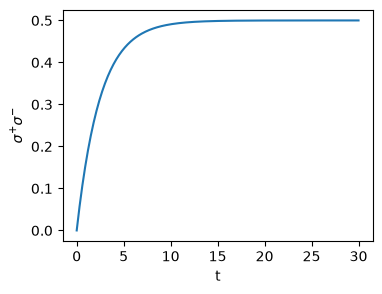

In [53]:
result = mesolve(L, psi0, times, c_ops, e_ops=sigmap()*sigmam())

n = result.expect[0]

import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(times,n)
plt.xlabel("t")
plt.ylabel(r"$\sigma^{+}\sigma^{-}$")
plt.show()

**Computing temporal correlation functions**

To compute temporal correlation function, we need to use the quantum regression theorem (see {numref}`ch:openqm-qme`.  QuTip has several functions which computes a correlaion function without explicitely envoking `mesolve`.  Two convenient ones are

* `correlation.correlation_2op_1t(H, psi0, times, c_ops, A, B)` &ensp; for $\langle A(\tau)B(0) \rangle$: 
* `correlation.correlation_3op_1t(H, psi0, times, c_ops, A, B, C)`&ensp; for $\langle A(0)B(\tau)C(0 \rangle$:     

where A, B< and C are operators.  Similarly to `mesolve`, `H` can be `L` and `psi0` can be `rho0`.

We are particularly interested in average over steady state, which is denoted as $\langle \cdots \rangle_{ss}$.  These functions calcuate the correlation starting from `psi0` or `rho0`.  To get the steady state correlation function, we must start with a steady state.  We already  know how to get a steady state.  Just plugin it.  Or you can set `None` in place of `psi0`.  Then, QuTiP uses a steady state automatically.

For the case of two operators, there is a special function for steady state correlation: &ensp; `correlation.correlation_ss(H, times, c_ops, A, B)`.


The following example compute $G^{(1)}(\tau) = \langle \sigma^{+}(t+\tau) \sigma^{-}(t)\rangle_{ss}$ and $G^{(2)}(\tau) = \langle \sigma^{+}(t) \sigma^{+}(t+\tau) \sigma^{-}(t+\tau)\sigma^{-}(t)\rangle_{ss}$ .

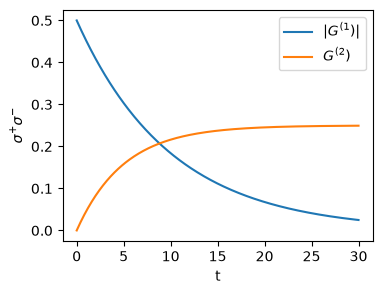

In [54]:
G1 = correlation.correlation_2op_1t(H, None, times, c_ops, sigmap(), sigmam())
G2 = correlation.correlation_3op_1t(H, None, times, c_ops, sigmap(), sigmap()*sigmam(), sigmam())
plt.figure(figsize=(4,3))
plt.plot(times,abs(G1),label=r"$|G^{(1})|$")
plt.plot(times,G2.real,label=r"$G^{(2})$")
plt.xlabel("t")
plt.ylabel(r"$\sigma^{+}\sigma^{-}$")
plt.legend(loc=1)
plt.show()

### Coherence functions

The coherence functions $g^{(1)}$ and $g^{(2)}$ are just the normalized version of the correlation functions $G^{(1)}$ and $G^{(2)}$. The normalization constant is  simply the intensity of the field and we can calculate it using `mesolve`.

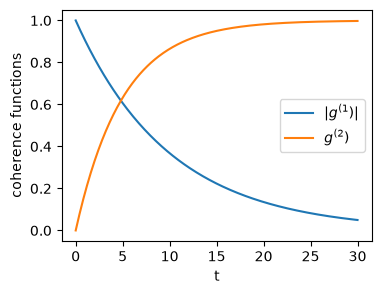

In [56]:
# get the normalization constant
norm1 = mesolve(H, rho_ss, times, c_ops, e_ops = sigmap()*sigmam()).expect[0]

# normalize G1 and G2
g1 = G1/norm1
g2 = G2/norm1**2

plt.figure(figsize=(4,3))
plt.plot(times,abs(g1),label=r"$|g^{(1})|$")
plt.plot(times,g2.real,label=r"$g^{(2})$")
plt.xlabel("t")
plt.ylabel("coherence functions")
plt.legend(loc=0)
plt.show()

Aactually, `QuTip` has build-in functions that compute both $G^{(n)}$ and $g^{(n)}$ at once. 

* `coherence_function_g1(H, None, times, c_ops, a)` &ensp; for   $g^{(1)}$ and $G^{(1)}$.
* `coherence_function_g2(H, None, times, c_ops, a)` &ensp; for   $g^{(2)}$ and $G^{(2)}$.

The following example generates the same results using the above functions.

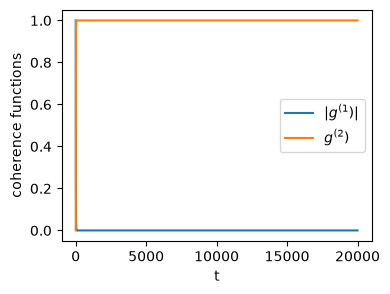

In [60]:
g1, G1 =coherence_function_g1(H, None, times, c_ops, sigmap())
g2, G2 =coherence_function_g2(H, None, times, c_ops, sigmap())

plt.figure(figsize=(4,3))
plt.plot(times,abs(g1),label=r"$|g^{(1})|$")
plt.plot(times,g2.real,label=r"$g^{(2})$")
plt.xlabel("t")
plt.ylabel("coherence functions")
plt.legend(loc=0)
plt.show()


## Quantum Trajectory

There is also build-in functions for quantum trajectory calculation.  In {numref}`ch:openqm-qme`, we calculated a quantum trajectory manually.  Monte Carlo solver `mcsolve()` generates quantum trajectories without hustle.  Since the quantum trajectory approach is mathematically equivalent to the corresponding quantum master equation, calling procedure is essentially the same, except for number of trajectories.  To get better statistics, we need many samplings.  If data is too noisy, increase the number of trajectories.  We just need to measure number operators.  Unfortunately, there is no function that analyzes the trajectory. We need to write a code.

**spike plot**

100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.15s


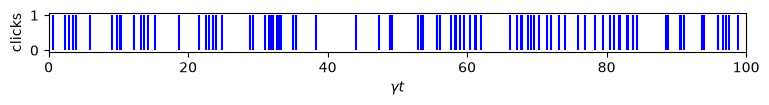

In [57]:
# define number opeator
n = sigmap()*sigmam()

# times
tmax = 2000 / gamma
tsample = 4000
times = np.linspace(0, tmax, tsample)

# initial state
psi0 = basis(2,1)

# we calculate only one trajectory 
result = mcsolve(H,psi0,times,c_ops,e_ops=n,ntraj=1)

# save the history of jumps
t_jump = np.array(result.col_times[0])

# plot only first 100 second
plt.figure(figsize=(9, 0.5))
plt.vlines(t_jump*gamma, 0, 1, color="b", label="system 1")
plt.xlim([0,100])
plt.ylabel("clicks")
plt.xlabel(r"$\gamma t$")
plt.show()

**waiting time distribution**

In [58]:
wtime = np.array([])
for i in range(len(t_jump)-1):
    wtime = np.append(wtime,t_jump[i+1]-t_jump[i])

mean = sum(wtime)/len(wtime)
dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)
print("mean waiting time  = ",mean)
print("standard deviation = ",dev)

if dev < 0.9*mean:
    print("likely sub-poissonian")
elif dev > 1.1*mean:
    print("likely super-poissonian")
else:
    print("likely poissonian")

mean waiting time  =  10.161569662227732
standard deviation =  10.264333733212087
likely poissonian


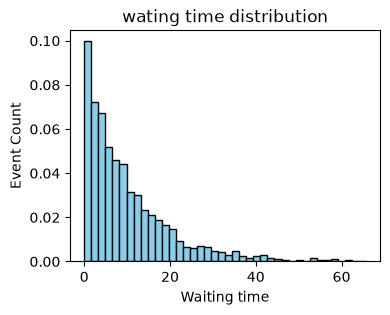

In [59]:
plt.figure(figsize=(4,3))
plt.hist(wtime, density=True, bins=40, color='skyblue', edgecolor='black')
plt.title("wating time distribution")
plt.xlabel("Waiting time")
plt.ylabel("Event Count")
plt.show()